# Session 5 — Grouped-Query Attention (GQA)

**Recap:** MHA (`num_kv_heads = num_heads`) and MQA (`num_kv_heads = 1`) are
two extremes. GQA makes `num_kv_groups` a tunable parameter in between.


## Derivation

Query heads are split into `num_kv_groups` groups; every query head in a
group shares one K/V head. Only `num_kv_groups` K/V heads are ever cached.

- `num_kv_groups = 1` -> identical to MQA.
- `num_kv_groups = num_heads` -> identical to MHA.


 GQA cache size sweep, num_heads=8,  
            seq_len=4096             
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ num_kv_groups ┃ cache bytes/layer ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ 1             │          64.00 KB │
│ 2             │         128.00 KB │
│ 4             │         256.00 KB │
│ 8             │         512.00 KB │
└───────────────┴───────────────────┘

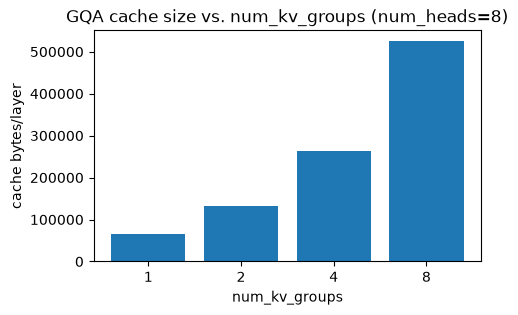

In [1]:
import torch
from kv_cache_variants.attention.gqa import GroupedQueryAttention
from kv_cache_variants.attention.mha import MultiHeadAttention
from kv_cache_variants.attention.mqa import MultiQueryAttention
from kv_cache_variants.memory_calc import kv_cache_bytes, human_bytes
from rich.console import Console
from rich.table import Table
import matplotlib.pyplot as plt

console = Console()
torch.manual_seed(0)
d_model, num_heads = 32, 8

table = Table(title="GQA cache size sweep, num_heads=8, seq_len=4096")
table.add_column("num_kv_groups")
table.add_column("cache bytes/layer", justify="right")
group_counts = [1, 2, 4, 8]
bytes_per_group = []
for groups in group_counts:
    gqa = GroupedQueryAttention(d_model, num_heads, groups)
    total = kv_cache_bytes(num_layers=1, num_kv_heads=groups, head_dim=d_model // num_heads, seq_len=4096)
    bytes_per_group.append(total)
    table.add_row(str(groups), human_bytes(total))
console.print(table)

plt.figure(figsize=(5, 3))
plt.bar([str(g) for g in group_counts], bytes_per_group)
plt.xlabel("num_kv_groups")
plt.ylabel("cache bytes/layer")
plt.title("GQA cache size vs. num_kv_groups (num_heads=8)")
plt.show()


## Numeric equivalence check

At the two boundary configs, GQA's output must exactly match MQA and MHA
respectively (same weights aren't shared here, so we check *shape*
equivalence and cached-head-count equivalence, not numerical output
equality, since these are separately-initialized modules).


In [2]:
gqa_as_mqa = GroupedQueryAttention(d_model, num_heads, num_kv_groups=1)
gqa_as_mha = GroupedQueryAttention(d_model, num_heads, num_kv_groups=num_heads)

x = torch.randn(1, 5, d_model)
_, kv_mqa_equiv = gqa_as_mqa(x)
_, kv_mha_equiv = gqa_as_mha(x)

print("GQA(num_kv_groups=1) cached K heads:", kv_mqa_equiv[0].shape[1], "== MQA's 1 head")
print("GQA(num_kv_groups=num_heads) cached K heads:", kv_mha_equiv[0].shape[1], f"== MHA's {num_heads} heads")
assert kv_mqa_equiv[0].shape[1] == 1
assert kv_mha_equiv[0].shape[1] == num_heads


GQA(num_kv_groups=1) cached K heads: 1 == MQA's 1 head
GQA(num_kv_groups=num_heads) cached K heads: 8 == MHA's 8 heads


```mermaid
flowchart LR
    subgraph Group1
        Q1[query head 1] --> KV1[shared K/V head A]
        Q2[query head 2] --> KV1
    end
    subgraph Group2
        Q3[query head 3] --> KV2[shared K/V head B]
        Q4[query head 4] --> KV2
    end
```


## Try it yourself

Change `num_heads` and the `group_counts` list above (e.g. `num_heads=16`,
groups `[1, 2, 4, 8, 16]`) and rerun — the reduction factor between adjacent
group counts is always exactly 2x when group counts double.


## Recap

GQA is the practical default in most modern open-weight models (e.g.
Llama-2-70B, Mistral) because it lets teams pick a cache-size/quality point
without committing to either MHA or MQA's extreme.

You are now ready to move to `06_mla.ipynb`.
